In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F 

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
import os
from PIL import Image
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

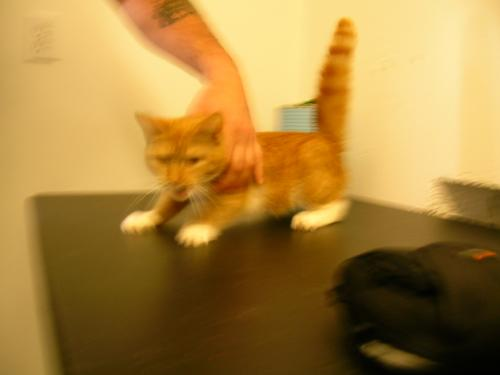

In [4]:
file_path = "../pytorch-for-deep-learning/Data/CATS_DOGS/"
with Image.open(file_path + "train/CAT/0.jpg") as img:
    display(img)

In [5]:
img_names = []
for folder, subfolders, filenames in os.walk(file_path):
    for img in filenames:
        img_names.append(folder + "/" + img)

In [6]:
len(img_names)

24994

In [7]:
img_sizes = []
rejected = []
for item in img_names:
    try:
        with Image.open(item) as img:
            img_sizes.append(img.size)
    except:
        rejected.append(item)


In [8]:
len(img_sizes), len(rejected)

(24994, 0)

In [9]:
df= pd.DataFrame(img_sizes)

In [10]:
df[0].describe(), df[1].describe()

(count    24994.000000
 mean       404.493518
 std        108.941802
 min         42.000000
 25%        323.000000
 50%        448.000000
 75%        500.000000
 max        500.000000
 Name: 0, dtype: float64,
 count    24994.000000
 mean       361.037129
 std         96.936811
 min         33.000000
 25%        302.000000
 50%        375.000000
 75%        421.000000
 max        500.000000
 Name: 1, dtype: float64)

In [11]:
df.head()

,0,1
0,500,375
1,500,333
2,350,466
3,360,277
4,500,375


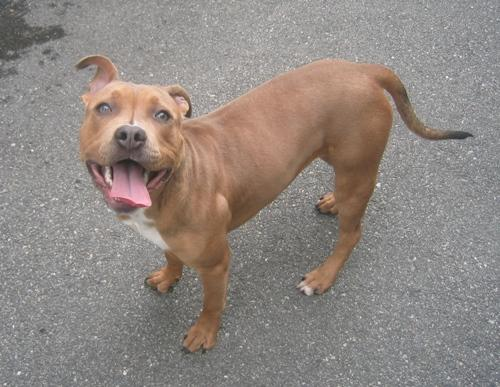

In [12]:
dog = Image.open(file_path + "train/DOG/14.jpg")
display(dog)

In [13]:
dog.getpixel((0,0))

(90, 95, 98)

In [14]:
transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor()
])

im = transform(dog)
im.shape

torch.Size([3, 150, 150])

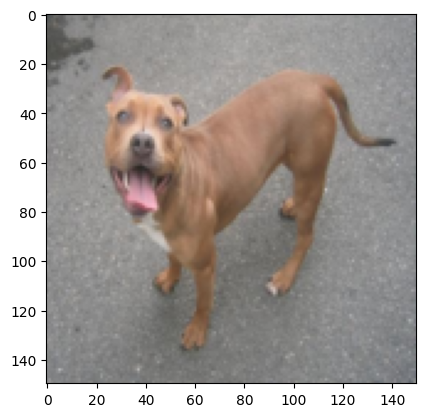

In [15]:
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)))

In [16]:
im # standardized between 0 and 1

tensor([[[0.3294, 0.3294, 0.3647,  ..., 0.5647, 0.5608, 0.5490],
         [0.3059, 0.3255, 0.3412,  ..., 0.5686, 0.5569, 0.5608],
         [0.3098, 0.3412, 0.3804,  ..., 0.6078, 0.5804, 0.5569],
         ...,
         [0.5098, 0.5020, 0.4941,  ..., 0.5137, 0.4627, 0.4471],
         [0.5216, 0.5882, 0.4980,  ..., 0.4353, 0.4941, 0.5098],
         [0.5569, 0.5843, 0.5373,  ..., 0.3922, 0.4353, 0.5412]],

        [[0.3490, 0.3490, 0.3765,  ..., 0.5686, 0.5647, 0.5529],
         [0.3216, 0.3412, 0.3490,  ..., 0.5725, 0.5608, 0.5647],
         [0.3255, 0.3529, 0.3843,  ..., 0.6118, 0.5843, 0.5608],
         ...,
         [0.5137, 0.5059, 0.4980,  ..., 0.5255, 0.4745, 0.4588],
         [0.5216, 0.5882, 0.5020,  ..., 0.4471, 0.5059, 0.5255],
         [0.5451, 0.5765, 0.5373,  ..., 0.4118, 0.4588, 0.5529]],

        [[0.3608, 0.3529, 0.3765,  ..., 0.5843, 0.5804, 0.5686],
         [0.3294, 0.3412, 0.3451,  ..., 0.5882, 0.5765, 0.5804],
         [0.3294, 0.3490, 0.3765,  ..., 0.6275, 0.6000, 0.

In [17]:
im[:,0,0]

tensor([0.3294, 0.3490, 0.3608])

In [18]:
np.array((90, 90, 90)) / 255

array([0.35294118, 0.35294118, 0.35294118])

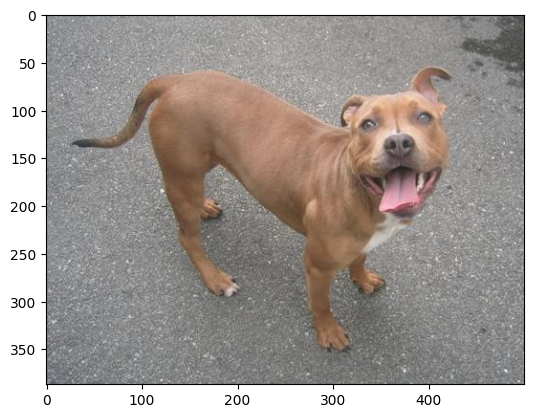

In [19]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1),
    transforms.ToTensor()
])

im = transform(dog)
im.shape

plt.imshow(np.transpose(im.numpy(), (1, 2, 0)))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5805322..2.5528543].


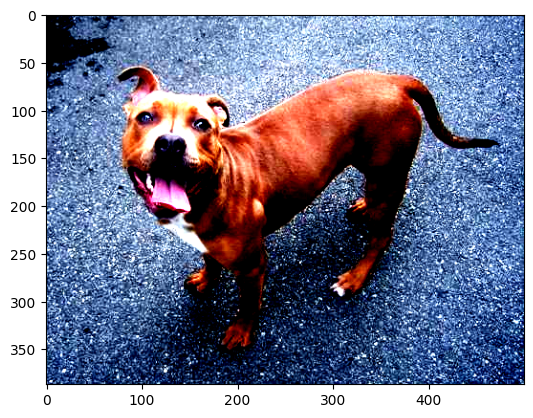

In [21]:


transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # imagenet mean and std dev

])
im = transform(dog)
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)))